In [ ]:
# CELL 1 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Đang tải tập dữ liệu (EL2.csv)...")
df_el2 = pd.read_csv('../dataset_ready/EL2.csv')
print(f"Tải dữ liệu thành công ! Kích thước: {df_el2.shape[0]:,} dòng, {df_el2.shape[1]} cột.")

Đang tải tập dữ liệu (EL2.csv)...


FileNotFoundError: [Errno 2] No such file or directory: 'EL2.csv'

In [ ]:
# CELL 2: LÀM SẠCH VÀ TIỀN XỬ LÝ DỮ LIỆU
print("Đang tiến hành làm sạch dữ liệu...")

# 1. Chuyển đổi định dạng thời gian (Datetime)
df_el2['order_purchase_timestamp'] = pd.to_datetime(df_el2['order_purchase_timestamp'])

# 2. Xử lý Missing Values (Dữ liệu thiếu)
# - Điền 'Unknown' cho các sản phẩm không xác định danh mục
df_el2['product_category_name'] = df_el2['product_category_name'].fillna('Unknown')

# - Điền giá trị trung vị (Median) cho các đơn hàng thiếu điểm đánh giá để không làm méo phân phối
median_score = df_el2['review_score'].median()
df_el2['review_score'] = df_el2['review_score'].fillna(median_score)

print("Làm sạch hoàn tất! Kiểm tra lại missing values:")
print(df_el2.isnull().sum())

Đang tiến hành làm sạch dữ liệu...
Làm sạch hoàn tất! Kiểm tra lại missing values:
order_id                    0
customer_id                 0
order_purchase_timestamp    0
customer_unique_id          0
customer_city               0
customer_state              0
product_id                  0
price                       0
freight_value               0
product_category_name       0
review_score                0
dtype: int64


In [ ]:
# CELL 3: TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN CƠ BẢN 

# Trích xuất Khung giờ, Ngày trong tháng, Tháng
df_el2['Hour'] = df_el2['order_purchase_timestamp'].dt.hour
df_el2['DayOfMonth'] = df_el2['order_purchase_timestamp'].dt.day
df_el2['Month'] = df_el2['order_purchase_timestamp'].dt.month

# Trích xuất Thứ trong tuần
df_el2['DayOfWeek_Num'] = df_el2['order_purchase_timestamp'].dt.dayofweek
day_mapping = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
df_el2['Weekday'] = df_el2['DayOfWeek_Num'].map(day_mapping)

# Phân loại Cuối tuần (Is_Weekend)
df_el2['Is_Weekend'] = df_el2['DayOfWeek_Num'].apply(lambda x: 1 if x >= 5 else 0)

print(" Đã tạo thành công các đặc trưng: Hour, DayOfMonth, Month, Weekday, Is_Weekend.")
print("\nXem trước dữ liệu:")
print(df_el2[['order_purchase_timestamp', 'Hour', 'Weekday', 'Is_Weekend']].head(3))

 Đã tạo thành công các đặc trưng: Hour, DayOfMonth, Month, Weekday, Is_Weekend.

Xem trước dữ liệu:
  order_purchase_timestamp  Hour Weekday  Is_Weekend
0      2017-10-02 10:56:33    10   Thứ 2           0
1      2018-07-24 20:41:37    20   Thứ 3           0
2      2018-08-08 08:38:49     8   Thứ 4           0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_1592\2645736903.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_sales, x='Month', y='price', palette='Blues_d', ax=axes[0])


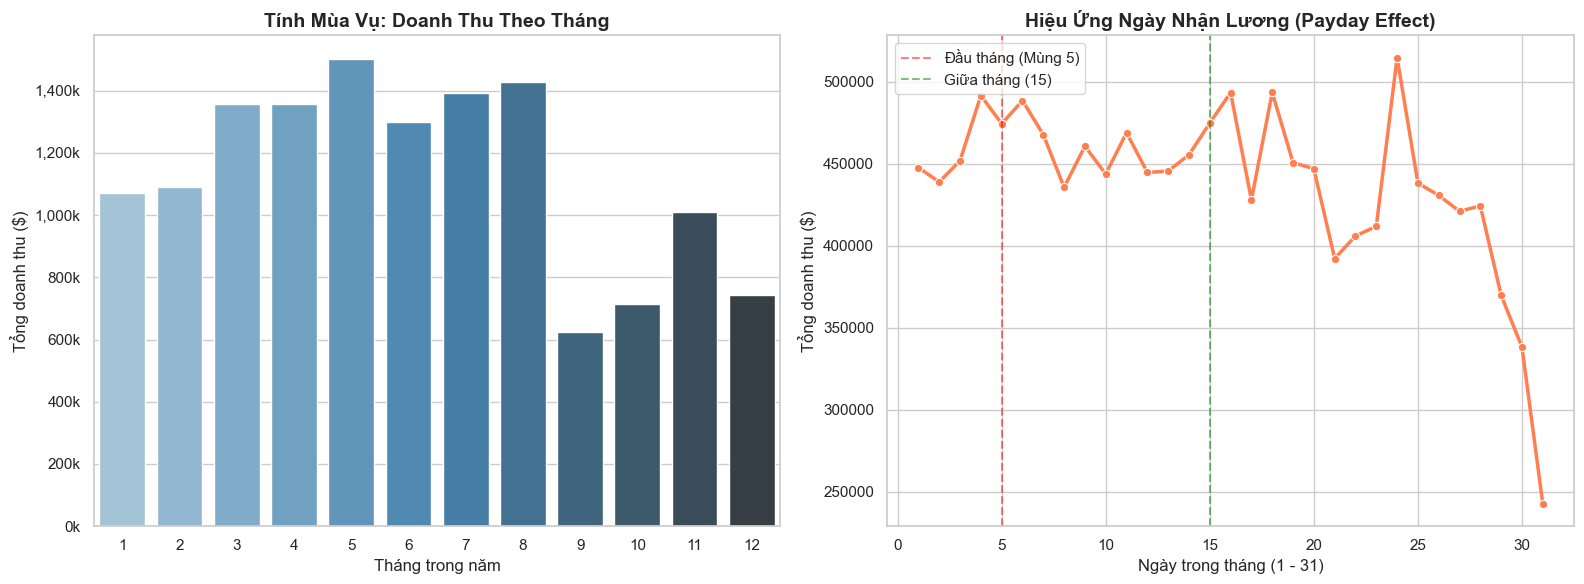

In [ ]:
# CELL 4: NHÓM ĐẶC TRƯNG THỜI GIAN (MÙA VỤ & PAYDAY EFFECT)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ Doanh thu theo tháng (Mùa vụ)
monthly_sales = df_el2.groupby('Month')['price'].sum().reset_index()
sns.barplot(data=monthly_sales, x='Month', y='price', palette='Blues_d', ax=axes[0])
axes[0].set_title('Tính Mùa Vụ: Doanh Thu Theo Tháng', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tháng trong năm')
axes[0].set_ylabel('Tổng doanh thu ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}k".format(int(x/1000))))

# 2. Biểu đồ Hiệu ứng nhận lương (Payday Effect)
daily_sales = df_el2.groupby('DayOfMonth')['price'].sum().reset_index()
sns.lineplot(data=daily_sales, x='DayOfMonth', y='price', marker='o', color='coral', linewidth=2.5, ax=axes[1])
axes[1].set_title('Hiệu Ứng Ngày Nhận Lương (Payday Effect)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ngày trong tháng (1 - 31)')
axes[1].set_ylabel('Tổng doanh thu ($)')

# Đánh dấu các mốc nhận lương phổ biến
axes[1].axvline(5, color='red', linestyle='--', alpha=0.5, label='Đầu tháng (Mùng 5)')
axes[1].axvline(15, color='green', linestyle='--', alpha=0.5, label='Giữa tháng (15)')
axes[1].legend()

plt.tight_layout()
plt.show()

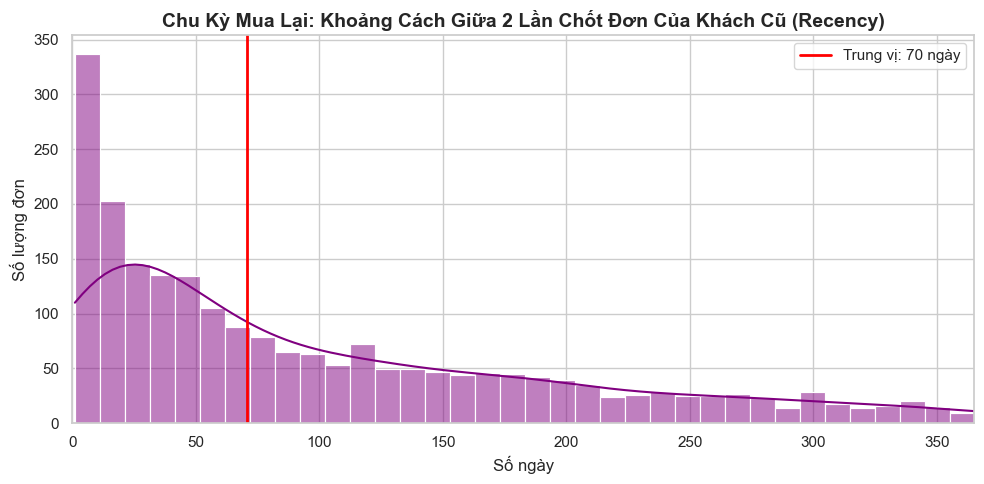

In [ ]:
# CELL 5: PHÂN TÍCH LÒNG TRUNG THÀNH (RETENTION & RECENCY)

# 1. Gắn nhãn Khách Cũ / Khách Mới vào DataFrame chính
customer_orders = df_el2.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders['Customer_Type'] = customer_orders['order_id'].apply(lambda x: 'Khách Cũ' if x > 1 else 'Khách Mới')
df_el2 = df_el2.merge(customer_orders[['customer_unique_id', 'Customer_Type']], on='customer_unique_id', how='left')

# 2. Tính toán Chu kỳ quay lại (Recency - Số ngày giữa 2 lần mua)
df_repeat = df_el2.sort_values(['customer_unique_id', 'order_purchase_timestamp']).copy()
df_repeat['Prev_Purchase_Date'] = df_repeat.groupby('customer_unique_id')['order_purchase_timestamp'].shift(1)
df_repeat['Days_Between_Orders'] = (df_repeat['order_purchase_timestamp'] - df_repeat['Prev_Purchase_Date']).dt.days

# Lọc các đơn lặp lại hợp lệ
recency_data = df_repeat[(df_repeat['Days_Between_Orders'] > 0)]

# 3. Trực quan hóa
plt.figure(figsize=(10, 5))
sns.histplot(recency_data['Days_Between_Orders'], bins=60, kde=True, color='purple')

median_recency = recency_data['Days_Between_Orders'].median()
plt.axvline(median_recency, color='red', linestyle='-', linewidth=2, label=f"Trung vị: {median_recency:.0f} ngày")

plt.title('Chu Kỳ Mua Lại: Khoảng Cách Giữa 2 Lần Chốt Đơn Của Khách Cũ (Recency)', fontsize=14, fontweight='bold')
plt.xlabel('Số ngày')
plt.ylabel('Số lượng đơn')
plt.xlim(0, 365) # Hiển thị trong 1 năm
plt.legend()
plt.tight_layout()
plt.show()

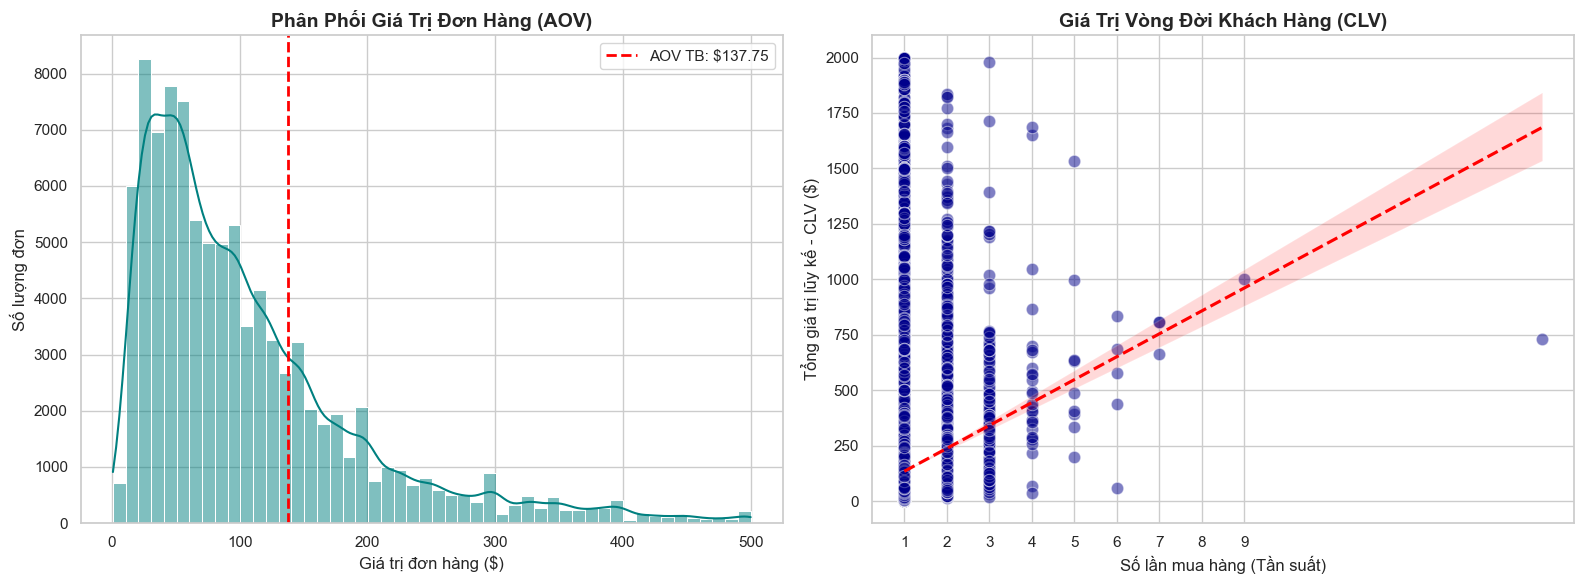

In [ ]:
# CELL 6: ĐẶC TRƯNG HÀNH VI CHI TIÊU (AOV & CLV)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Doanh thu trên mỗi đơn hàng (AOV)
order_values = df_el2.groupby('order_id')['price'].sum().reset_index()
# Lọc dưới 500$ để biểu đồ không bị nhiễu bởi các đơn quá đột biến
sns.histplot(order_values[order_values['price'] < 500]['price'], bins=50, kde=True, color='teal', ax=axes[0])

aov_mean = order_values['price'].mean()
axes[0].axvline(aov_mean, color='red', linestyle='--', linewidth=2, label=f"AOV TB: ${aov_mean:.2f}")
axes[0].set_title('Phân Phối Giá Trị Đơn Hàng (AOV)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá trị đơn hàng ($)')
axes[0].set_ylabel('Số lượng đơn')
axes[0].legend()

# 2. Giá trị Vòng đời Khách hàng (CLV)
clv_data = df_el2.groupby('customer_unique_id').agg(
    CLV=('price', 'sum'), 
    Order_Count=('order_id', 'nunique')
).reset_index()

plot_clv = clv_data[clv_data['CLV'] < 2000] # Lọc outlier để dễ nhìn
sns.scatterplot(data=plot_clv, x='Order_Count', y='CLV', alpha=0.5, color='darkblue', s=80, ax=axes[1])
sns.regplot(data=plot_clv, x='Order_Count', y='CLV', scatter=False, color='red', line_kws={"linestyle": "--"}, ax=axes[1])

axes[1].set_title('Giá Trị Vòng Đời Khách Hàng (CLV)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số lần mua hàng (Tần suất)')
axes[1].set_ylabel('Tổng giá trị lũy kế - CLV ($)')
axes[1].set_xticks(range(1, 10))

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_1592\3688895884.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_el2[df_el2['customer_state'].isin(top_states)],


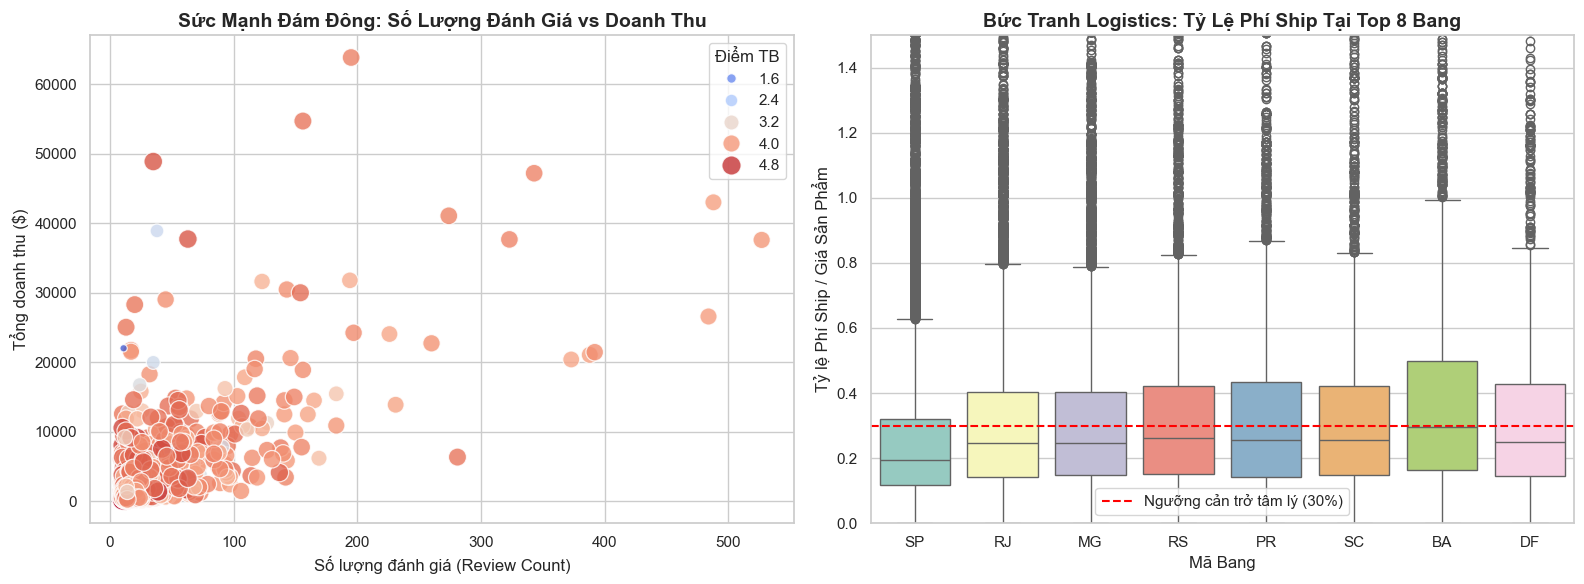

In [ ]:
# CELL 7: ĐẶC TRƯNG SẢN PHẨM & LOGISTICS
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Sự phổ biến của sản phẩm (Review Count vs Doanh Thu)
product_reviews = df_el2.groupby('product_id').agg(
    Review_Count=('review_score', 'count'),
    Avg_Review=('review_score', 'mean'),
    Total_Revenue=('price', 'sum')
).reset_index()

popular_products = product_reviews[product_reviews['Review_Count'] >= 10]
sns.scatterplot(data=popular_products, x='Review_Count', y='Total_Revenue', 
                hue='Avg_Review', palette='coolwarm', size='Avg_Review', 
                sizes=(20, 200), alpha=0.8, ax=axes[0])

axes[0].set_title('Sức Mạnh Đám Đông: Số Lượng Đánh Giá vs Doanh Thu', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng đánh giá (Review Count)')
axes[0].set_ylabel('Tổng doanh thu ($)')
axes[0].legend(title='Điểm TB')

# 2. Đặc trưng Logistics - Tỷ lệ Phí Ship (Freight Ratio)
df_el2['Freight_Ratio'] = df_el2['freight_value'] / df_el2['price']
top_states = df_el2['customer_state'].value_counts().head(8).index

sns.boxplot(data=df_el2[df_el2['customer_state'].isin(top_states)], 
            x='customer_state', y='Freight_Ratio', order=top_states, palette='Set3', ax=axes[1])

axes[1].set_title('Bức Tranh Logistics: Tỷ Lệ Phí Ship Tại Top 8 Bang', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mã Bang')
axes[1].set_ylabel('Tỷ lệ Phí Ship / Giá Sản Phẩm')
axes[1].set_ylim(0, 1.5)
axes[1].axhline(0.3, color='red', linestyle='--', label='Ngưỡng cản trở tâm lý (30%)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# CELL 8: TỔNG HỢP FINAL DATASET & CHIA TRAIN/TEST (80/20)
import pandas as pd

print("Đang tổng hợp Final Dataset...")

# 1. Gom nhóm theo Ngày (Daily Aggregation)
df_el2['Date'] = df_el2['order_purchase_timestamp'].dt.date
daily_data = df_el2.groupby('Date').agg(
    Total_Revenue=('price', 'sum'),
    Total_Orders=('order_id', 'nunique'),
    Avg_Freight_Ratio=('Freight_Ratio', 'mean') # Trung bình tỷ lệ phí ship trong ngày
).reset_index()

# Bắt buộc phải sắp xếp theo thời gian cho bài toán Time-Series
daily_data = daily_data.sort_values('Date').reset_index(drop=True)

# 2. Tạo đặc trưng AOV hàng ngày
daily_data['Daily_AOV'] = daily_data['Total_Revenue'] / daily_data['Total_Orders']

# 3. Tạo các biến Trễ (Lag & Rolling) - Tuyệt chiêu chống rò rỉ dữ liệu
daily_data['Sales_Lag_1'] = daily_data['Total_Revenue'].shift(1)  # Doanh thu hôm qua
daily_data['Sales_Lag_7'] = daily_data['Total_Revenue'].shift(7)  # Doanh thu tuần trước cùng ngày
daily_data['Rolling_Mean_7d'] = daily_data['Total_Revenue'].rolling(window=7).mean().shift(1) # Đà bán hàng 7 ngày qua

# 4. Bổ sung Đặc trưng thời gian
daily_data['Date'] = pd.to_datetime(daily_data['Date'])
daily_data['DayOfWeek'] = daily_data['Date'].dt.dayofweek
daily_data['Is_Weekend'] = daily_data['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
daily_data['DayOfMonth'] = daily_data['Date'].dt.day
daily_data['Month'] = daily_data['Date'].dt.month

# Drop các dòng NaN (do hàm shift không có dữ liệu ở những ngày đầu tiên)
final_dataset = daily_data.dropna().copy()

# 5. CHIA TẬP TRAIN / TEST THEO THỜI GIAN (80/20)
split_idx = int(len(final_dataset) * 0.8)

# Định nghĩa các biến đầu vào (Features)
features = ['Daily_AOV', 'Avg_Freight_Ratio', 'Sales_Lag_1', 'Sales_Lag_7', 
            'Rolling_Mean_7d', 'DayOfWeek', 'Is_Weekend', 'DayOfMonth', 'Month']

# Tách tập Train (Quá khứ)
X_train = final_dataset.iloc[:split_idx][features]
y_train = final_dataset.iloc[:split_idx]['Total_Revenue']

# Tách tập Test (Tương lai)
X_test = final_dataset.iloc[split_idx:][features]
y_test = final_dataset.iloc[split_idx:]['Total_Revenue']

print("Đã hoàn tất chia tập dữ liệu")
print("-" * 50)
print(f"Kích thước X_train (Dữ train): {X_train.shape} | y_train (Mục tiêu học): {y_train.shape}")
print(f"Kích thước X_test (Dữ test):  {X_test.shape} | y_test (Mục tiêu thi):  {y_test.shape}")
print("-" * 50)
print("Tập dữ liệu đã SẴN SÀNG 100% để đưa vào mô hình")

Đang tổng hợp Final Dataset...
Đã hoàn tất chia tập dữ liệu
--------------------------------------------------
Kích thước X_train (Dữ train): (487, 9) | y_train (Mục tiêu học): (487,)
Kích thước X_test (Dữ test):  (122, 9) | y_test (Mục tiêu thi):  (122,)
--------------------------------------------------
Tập dữ liệu đã SẴN SÀNG 100% để đưa vào mô hình


In [ ]:
import os

print("Đang tiến hành xuất dữ liệu ra file CSV...")

# Tạo thư mục 'dataset_ready' để chứa các file cho gọn gàng (nếu chưa có)
output_dir = '../dataset_ready'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 1. Xuất tập Huấn luyện (Train)
X_train.to_csv(f'{output_dir}/X_train.csv', index=False)
y_train.to_csv(f'{output_dir}/y_train.csv', index=False)

# 2. Xuất tập Kiểm thử (Test)
X_test.to_csv(f'{output_dir}/X_test.csv', index=False)
y_test.to_csv(f'{output_dir}/y_test.csv', index=False)

# 3. Xuất toàn bộ bảng Final Dataset (Đề phòng sau này muốn dùng lại)
final_dataset.to_csv(f'{output_dir}/final_dataset_full.csv', index=False)

print("Các file đã được lưu trong thư mục 'dataset_ready':")
print("  - X_train.csv")
print("  - y_train.csv")
print("  - X_test.csv")
print("  - y_test.csv")
print("  - final_dataset_full.csv")

Đang tiến hành xuất dữ liệu ra file CSV...
Các file đã được lưu trong thư mục 'dataset_ready':
  - X_train.csv
  - y_train.csv
  - X_test.csv
  - y_test.csv
  - final_dataset_full.csv


In [ ]:
import os

print("Đang tiến hành xuất dữ liệu ra file CSV...")

# Tạo thư mục 'dataset_ready' để chứa các file cho gọn gàng (nếu chưa có)
output_dir = '../dataset_ready'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 1. Xuất tập Huấn luyện (Train)
X_train.to_csv(f'{output_dir}/X_train.csv', index=False)
y_train.to_csv(f'{output_dir}/y_train.csv', index=False)

# 2. Xuất tập Kiểm thử (Test)
X_test.to_csv(f'{output_dir}/X_test.csv', index=False)
y_test.to_csv(f'{output_dir}/y_test.csv', index=False)

# 3. Xuất toàn bộ bảng Final Dataset (Đề phòng sau này muốn dùng lại)
final_dataset.to_csv(f'{output_dir}/final_dataset_full.csv', index=False)

print("Các file đã được lưu trong thư mục 'dataset_ready':")
print("  - X_train.csv")
print("  - y_train.csv")
print("  - X_test.csv")
print("  - y_test.csv")
print("  - final_dataset_full.csv")